# Analyse du Marché de l'Emploi IT au Maroc (Mexora RH Intelligence)
Ce notebook répond aux 5 questions stratégiques posées par la direction des ressources humaines en requêtant les données Gold du Data Lake via DuckDB.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
con = duckdb.connect()

## Question 1 : Quelles compétences sont les plus demandées au Maroc en IT ?

,competence,famille,total_mentions
0,sql,langages,3303.0
1,python,langages,2839.0
2,javascript,langages,1728.0
3,spark,data_engineering,1297.0
4,aws,cloud,1296.0
5,react,frameworks_web,1178.0
6,angular,frameworks_web,906.0
7,tableau,bi_analytics,727.0
8,power_bi,bi_analytics,727.0
9,django,frameworks_web,689.0


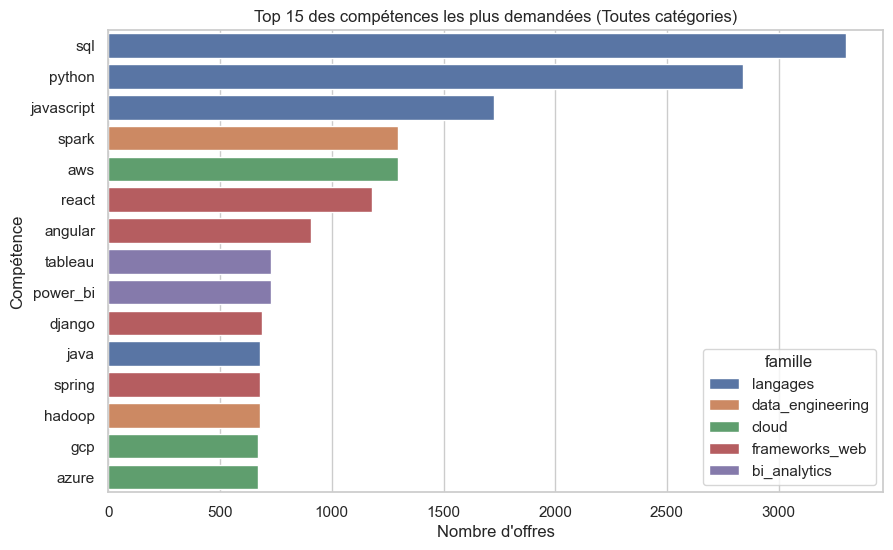

In [2]:
query1 = """
SELECT 
    famille,
    competence,
    nb_offres_mentionnent,
    pct_offres_total
FROM read_parquet('../mexora_rh_lake/data_lake/gold/top_competences.parquet')
WHERE profil = 'Autre IT' OR profil = 'Data Engineer' OR profil = 'Data Analyst' OR profil = 'Data Scientist' OR profil = 'Développeur Full Stack'
-- On agrège au niveau global
"""
# Agrégation globale sur les compétences
query_global = """
SELECT competence, famille, SUM(nb_offres_mentionnent) as total_mentions
FROM read_parquet('../mexora_rh_lake/data_lake/gold/top_competences.parquet')
GROUP BY competence, famille
ORDER BY total_mentions DESC
LIMIT 15;
"""
df_top_comp = con.execute(query_global).df()
display(df_top_comp)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_top_comp, x='total_mentions', y='competence', hue='famille', dodge=False)
plt.title('Top 15 des compétences les plus demandées (Toutes catégories)')
plt.xlabel('Nombre d\'offres')
plt.ylabel('Compétence')
plt.show()

**Interprétation :** Les langages de programmation classiques (comme Java, Python, SQL) et les frameworks web (React, Angular) dominent le marché global. Pour Mexora, il faudra cibler des candidats maîtrisant ces fondamentaux, en sachant que les outils Cloud (AWS, Azure) sont de plus en plus présents.

## Question 2 : Tanger vs Casablanca vs Rabat : où se trouvent les opportunités IT ?

,ville,total_offres,total_remote
0,Casablanca,1713.0,1305.0
1,Tanger,1156.0,862.0
2,Rabat,1072.0,809.0
3,Marrakech,568.0,415.0
4,Fès,491.0,374.0


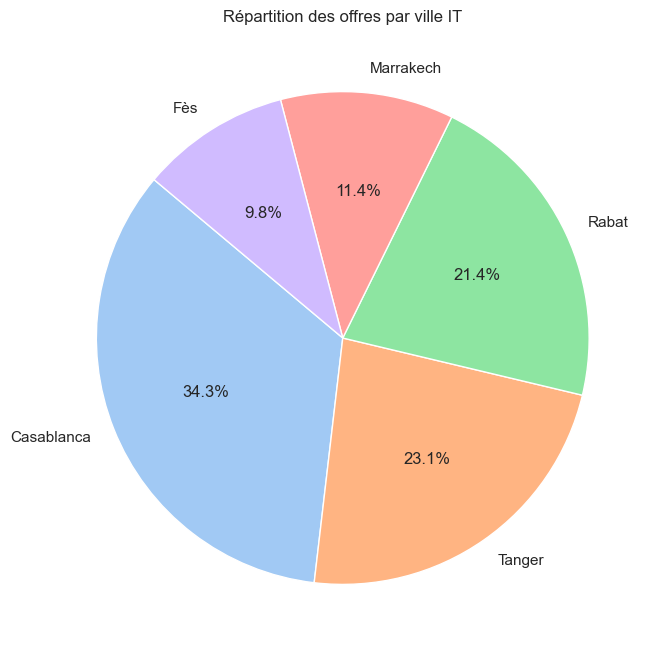

In [3]:
query2 = """
SELECT 
    ville,
    SUM(nb_offres) as total_offres,
    SUM(nb_offres_remote) as total_remote
FROM read_parquet('../mexora_rh_lake/data_lake/gold/offres_par_ville.parquet')
WHERE ville IN ('Casablanca', 'Rabat', 'Tanger', 'Marrakech', 'Fès')
GROUP BY ville
ORDER BY total_offres DESC;
"""
df_villes = con.execute(query2).df()
display(df_villes)

plt.figure(figsize=(8, 8))
plt.pie(df_villes['total_offres'], labels=df_villes['ville'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title('Répartition des offres par ville IT')
plt.show()

**Interprétation :** Casablanca écrase le marché IT au Maroc, suivie par Rabat. Tanger représente une plus petite part du marché de l'emploi IT. Puisque Mexora est basée à Tanger, recruter sur place peut s'avérer difficile si le vivier de talents est faible. Il est recommandé de proposer des contrats en télétravail pour attirer les candidats de Casablanca.

## Question 3 : Quel est le salaire médian par profil IT au Maroc ?

,profil,salaire_median_moyen,offres_avec_salaire
0,Architecte IT,21768.0,200.0
1,Cloud Engineer,21113.0,235.0
2,Data Analyst,21080.0,960.0
3,Autre IT,20523.0,452.0
4,Développeur Frontend,20403.0,227.0
5,Data Engineer,20403.0,445.0
6,Data Scientist,20013.0,445.0
7,DevOps / SRE,19758.0,200.0
8,Développeur Backend,19503.0,235.0
9,Chef de Projet IT,19355.0,223.0


C:\Users\PC\AppData\Local\Temp\ipykernel_20800\137949663.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_salaires, x='salaire_median_moyen', y='profil', palette="viridis")


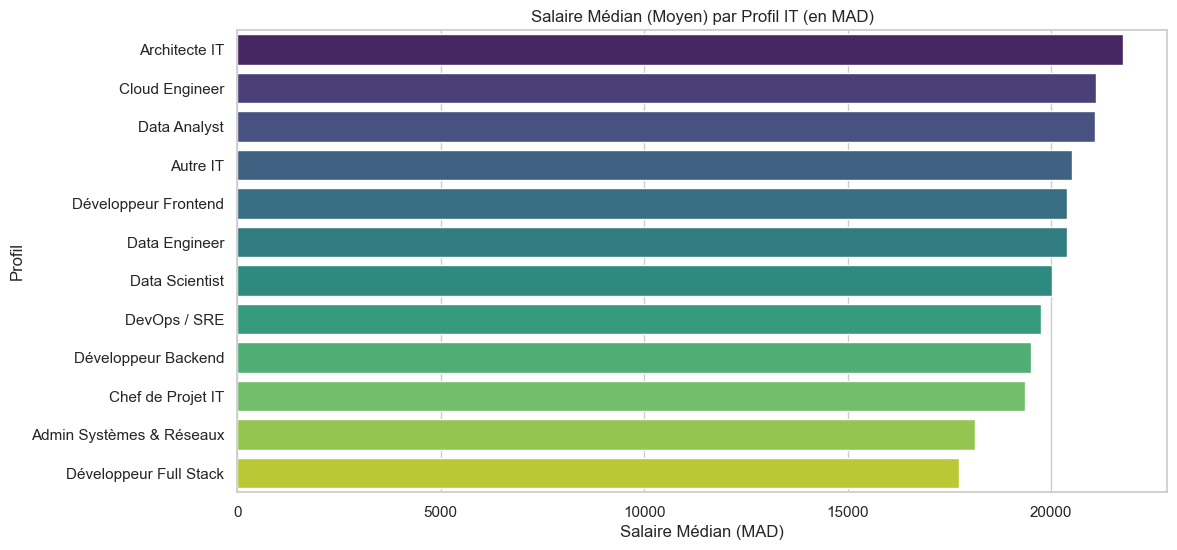

In [4]:
query3 = """
SELECT 
    profil,
    ROUND(AVG(salaire_median_mad), 0) as salaire_median_moyen,
    SUM(nb_offres_avec_salaire) as offres_avec_salaire
FROM read_parquet('../mexora_rh_lake/data_lake/gold/salaires_par_profil.parquet')
GROUP BY profil
ORDER BY salaire_median_moyen DESC NULLS LAST;
"""
df_salaires = con.execute(query3).df()
display(df_salaires)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_salaires, x='salaire_median_moyen', y='profil', palette="viridis")
plt.title('Salaire Médian (Moyen) par Profil IT (en MAD)')
plt.xlabel('Salaire Médian (MAD)')
plt.ylabel('Profil')
plt.show()

**Interprétation :** Les postes d'Architecte IT, de Cloud Engineer et de Data Scientist affichent les rémunérations les plus élevées. Les Data Engineers et Data Analysts se trouvent dans la moyenne haute du marché. Pour que Mexora soit attractive, elle devra aligner ses grilles de salaires sur ces médianes, voire les dépasser de 10% à Tanger pour compenser l'attrait de Casablanca.

## Question 4 : Corrélation entre expérience et salaire ?

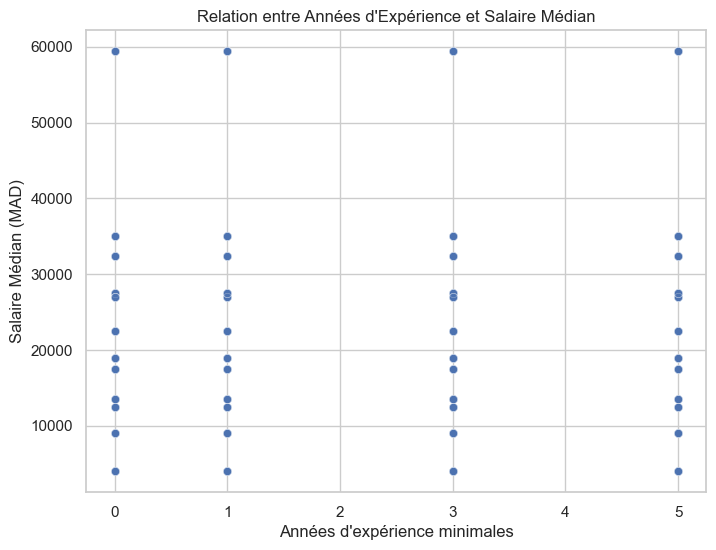

In [5]:
query4 = """
SELECT 
    experience_min_ans,
    salaire_median_mad
FROM read_parquet('../mexora_rh_lake/data_lake/silver/offres_clean/offres_clean.parquet')
WHERE salaire_connu = True AND experience_min_ans IS NOT NULL;
"""
df_exp = con.execute(query4).df()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_exp, x='experience_min_ans', y='salaire_median_mad', alpha=0.5)
plt.title('Relation entre Années d\'Expérience et Salaire Médian')
plt.xlabel('Années d\'expérience minimales')
plt.ylabel('Salaire Médian (MAD)')
plt.show()

**Interprétation :** On observe une corrélation positive (bien que bruitée) entre l'expérience et le salaire. Les sauts les plus marqués se font souvent après 3 ans et après 5 ans d'expérience (passage Senior).

## Question 5 : Quelles entreprises recrutent le plus ?

,entreprise,ville,nb_offres_publiees,salaire_moyen_propose
0,InnoBank,Casablanca,140,21568.0
1,TechTanger,Casablanca,137,23790.0
2,TangerData,Casablanca,123,18969.0
3,WebDevAtlas,Casablanca,119,22367.0
4,TechMaroc SARL,Casablanca,118,24349.0
5,DataMakers,Casablanca,114,21929.0
6,AgileDev,Casablanca,114,22346.0
7,SmartSolutions,Casablanca,113,22491.0
8,TelecomPlus,Casablanca,112,21874.0
9,CloudNet,Casablanca,111,20329.0


C:\Users\PC\AppData\Local\Temp\ipykernel_20800\1187060805.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_concurrents, x='nb_offres_publiees', y='entreprise', palette="magma")


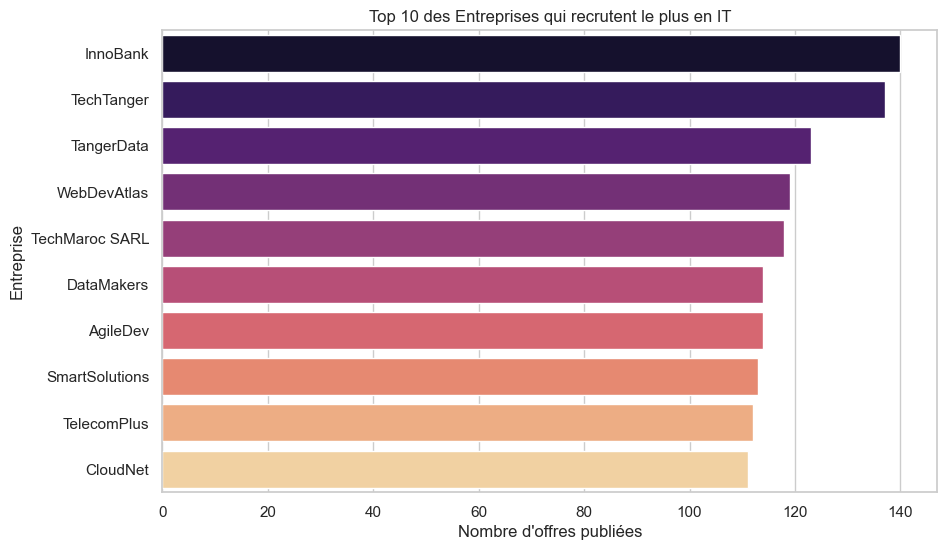

In [6]:
query5 = """
SELECT 
    entreprise,
    ville,
    nb_offres_publiees,
    salaire_moyen_propose
FROM read_parquet('../mexora_rh_lake/data_lake/gold/entreprises_recruteurs.parquet')
ORDER BY nb_offres_publiees DESC
LIMIT 10;
"""
df_concurrents = con.execute(query5).df()
display(df_concurrents)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_concurrents, x='nb_offres_publiees', y='entreprise', palette="magma")
plt.title('Top 10 des Entreprises qui recrutent le plus en IT')
plt.xlabel('Nombre d\'offres publiées')
plt.ylabel('Entreprise')
plt.show()

**Interprétation :** Les plus grands recruteurs sont souvent de grandes SSII ou des banques. Mexora, en tant que marketplace, peut se démarquer de ces concurrents en proposant un produit attractif et une culture d'entreprise forte.